In [8]:
##Imports
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
##Creating the connection
conn = duckdb.connect("../ecommerce.duckdb")

In [10]:
##Verifying tables
conn.execute("SHOW TABLES").fetchdf()

,name
0,dim_brands
1,dim_categories
2,dim_customers
3,dim_products
4,fact_order_items
5,orders


#### Sales Analytics

This notebook analyzes revenue trends, customer purchasing behavior, and category performance using DuckDB and SQL analytics.

#### Total Revenue

In [11]:
conn.execute("""
SELECT
    ROUND(SUM(quantity * unit_price * (1 - discount)), 2) AS total_revenue
FROM fact_order_items
""").fetchdf()

,total_revenue
0,50656421.24


#### Revenue by Category

In [13]:
category_revenue_df = conn.execute("""
SELECT
    c.category_name,
    ROUND(SUM(f.quantity * f.unit_price * (1 - f.discount)), 2) AS revenue
FROM fact_order_items f
JOIN dim_products p
    ON f.product_id = p.product_id
JOIN dim_categories c
    ON p.category_id = c.category_id
GROUP BY c.category_name
ORDER BY revenue DESC
""").fetchdf()

category_revenue_df

,category_name,revenue
0,Fashion,35343218.96
1,Toys,31934681.80
2,Sports,30890160.21
3,Beauty,30482232.13
4,Home,26295032.19
5,Electronics,25069252.73
6,Books,22611106.94


Electronics and Sports generate the highest revenue contribution across all categories.

#### Barplot

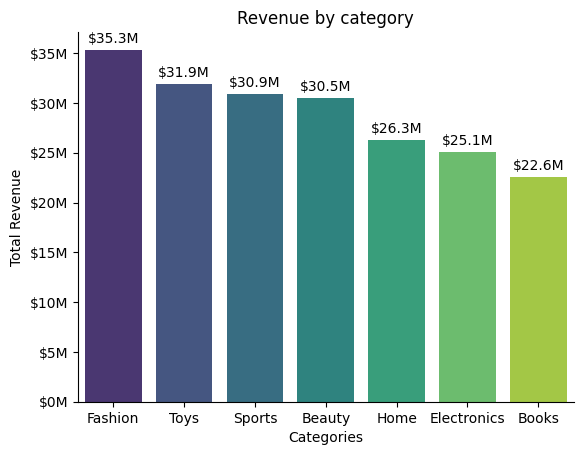

In [ ]:
import matplotlib.ticker as ticker

ax =sns.barplot(data=category_revenue_df, x= "category_name", y= "revenue", hue="category_name",
                palette="viridis")
plt.xlabel("Categories")
plt.ylabel("Total Revenue")

for x in ax.containers:
    labels = [
        f'${v.get_height()/1_000_000:.1f}M'
        for v in x
    ]
    ax.bar_label(
        x,
        labels=labels,
        padding=3
    )

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'${x/1_000_000:.0f}M'
    )
)

plt.title("Revenue by category")
sns.despine()
plt.show()

#### Windows Functions & CTEs

In [ ]:
conn.execute("""
WITH customer_revenue AS (
    SELECT
        o.customer_id, ROUND(SUM(f.quantity * f.unit_price * (1 - f.discount)), 2) AS revenue
    FROM fact_order_items f
    JOIN orders o
        ON f.order_id = o.order_id
    GROUP BY o.customer_id
)

SELECT
    customer_id,
    revenue,
    RANK() OVER(ORDER BY revenue DESC) AS customer_rank
FROM customer_revenue
ORDER BY revenue DESC
LIMIT 10
""").fetchdf()

#### Monthly Revenue Analysis

In [42]:
monthly_revenue_df = conn.execute("""
SELECT
    DATE_TRUNC('month', o.order_date) AS month, 
    ROUND(SUM(f.quantity * f.unit_price * (1 - f.discount)), 2) AS revenue
FROM fact_order_items f
JOIN orders o
    ON f.order_id = o.order_id
GROUP BY month
ORDER BY month
""").fetchdf()

monthly_revenue_df

,month,revenue
0,2024-05-01,2049628.32
1,2024-06-01,4070311.38
2,2024-07-01,3756072.34
3,2024-08-01,4610873.58
4,2024-09-01,4664440.87
5,2024-10-01,4281203.03
6,2024-11-01,4223608.52
7,2024-12-01,4727354.93
8,2025-01-01,4237355.43
9,2025-02-01,3710041.78


#### Lineplot

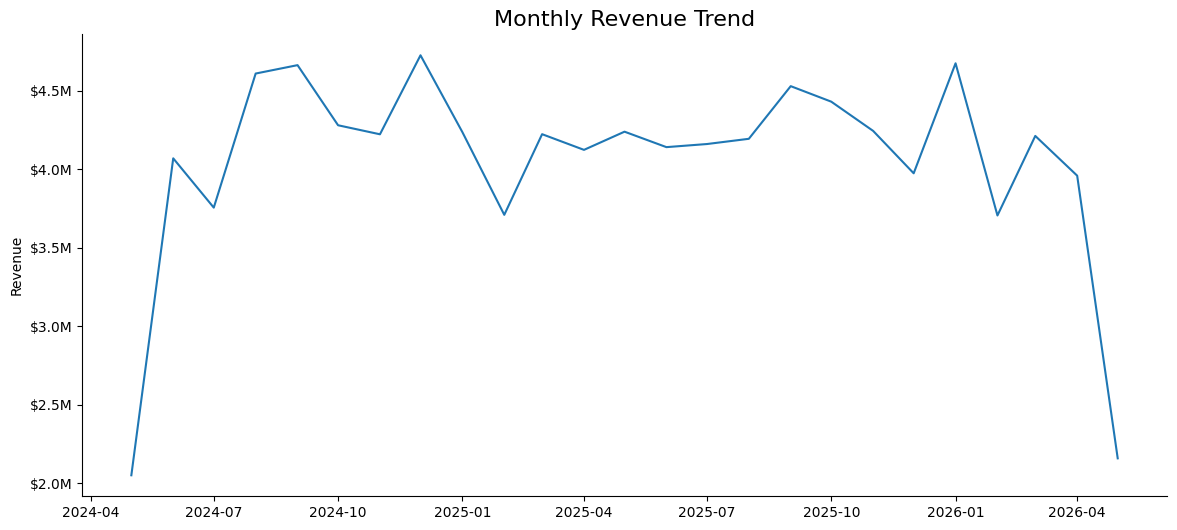

In [53]:
plt.figure(figsize=(14,6))

ax = sns.lineplot(
    data=monthly_revenue_df,
    x="month",
    y="revenue",
)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'${x/1_000_000:.1f}M'
    )
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
)

plt.xlabel("")
plt.ylabel("Revenue")

sns.despine()

plt.show()

#### Rolling Average (3 months)

In [48]:
rolling_revenue_df = conn.execute("""
WITH monthly_revenue AS (
    SELECT
        DATE_TRUNC('month', o.order_date) AS month,
        ROUND(SUM(f.quantity * f.unit_price * (1 - f.discount)), 2) AS revenue
    FROM fact_order_items f
    JOIN orders o
        ON f.order_id = o.order_id
    GROUP BY month
)

SELECT
    month,
    revenue,
    ROUND(AVG(revenue) OVER(ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2) AS rolling_3m_avg

FROM monthly_revenue

ORDER BY month
""").fetchdf()

#### Dual Visualization

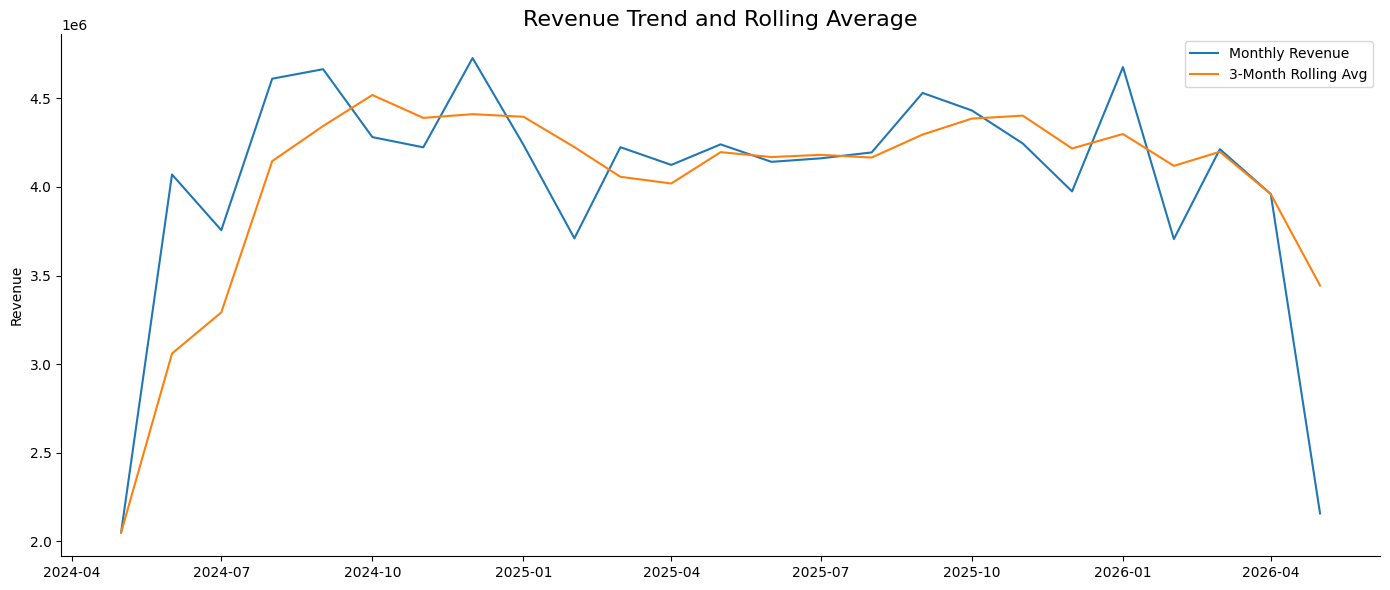

In [54]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=rolling_revenue_df,
    x="month",
    y="revenue",
    label="Monthly Revenue",
)

sns.lineplot(
    data=rolling_revenue_df,
    x="month",
    y="rolling_3m_avg",
    label="3-Month Rolling Avg",
)

plt.title(
    "Revenue Trend and Rolling Average",
    fontsize=16
)

plt.xlabel("")
plt.ylabel("Revenue")

sns.despine()

plt.tight_layout()

plt.show()